In [11]:
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# 載入 CIFAR-10
(x_traino, y_traino), (x_test, y_test) = cifar10.load_data()
x_train=x_traino[:40000]
y_train=y_traino[:40000]
x_testd=x_traino[40000:]
y_testd=y_traino[40000:]
print("訓練資料形狀:", x_train.shape)
print("訓練資料2形狀:", x_testd.shape)
print("測試資料形狀:", x_test.shape)




訓練資料形狀: (40000, 32, 32, 3)
訓練資料2形狀: (10000, 32, 32, 3)
測試資料形狀: (10000, 32, 32, 3)


In [12]:
# from tensorflow.keras import mixed_precision
# mixed_precision.set_global_policy("mixed_float16")

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")
print("Current mixed precision policy:", tf.keras.mixed_precision.global_policy())

Current mixed precision policy: <Policy "mixed_float16">


In [13]:
from keras.utils import to_categorical
import cv2
# 標籤轉換成 one-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)
y_testd = to_categorical(y_testd, 10)


x_train_hsv = np.array([cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(np.float32) for img in x_train])
x_train_hsv[:, :, :, 0] /= 179
x_train_hsv[:, :, :, 1:] /= 255


x_test_hsv = np.array([cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(np.float32) for img in x_test])
x_test_hsv[:, :, :, 0] /= 179
x_test_hsv[:, :, :, 1:] /= 255


x_testd_hsv = np.array([cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(np.float32) for img in x_testd])
x_testd_hsv[:, :, :, 0] /= 179
x_testd_hsv[:, :, :, 1:] /= 255



# 正規化圖片像素值到 [0,1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_testd = x_testd.astype("float32") / 255.0

# RGB + HSV
x_train_rgb_hsv = np.concatenate([x_train, x_train_hsv], axis=-1)
x_test_rgb_hsv = np.concatenate([x_test, x_test_hsv], axis=-1)
x_testd = np.concatenate([x_testd, x_testd_hsv], axis=-1)


In [14]:
print(x_train_rgb_hsv.shape)
print(x_test_rgb_hsv.shape)

(40000, 32, 32, 6)
(10000, 32, 32, 6)


In [15]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,Input,Concatenate
from keras import layers, models



def cb(inputs):

    x = layers.Conv2D(32, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    return x


def testmod(input_shape):
    inputs = Input(input_shape, name="input_layer")
    rgb = inputs[:, :, :, :3]
    hsv = inputs[:, :, :, 3:]

    # 合併
    x = Concatenate()([cb(rgb), cb(hsv)])

    #x=layers.Flatten()(x)
    x=layers.GlobalAveragePooling2D()(x)
    x=layers.Dense(64)(x)
    x=layers.Dropout(0.3)(x)
    x=layers.BatchNormalization()(x)
    x=layers.Activation('relu')(x)
    x=layers.Dense(10, activation='softmax')(x)

    return models.Model(inputs=inputs, outputs=x)

In [16]:
m=testmod(input_shape=(32,32,6))
optimizer = tf.keras.optimizers.Adam(
    learning_rate=2e-4
)
m.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [17]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)


early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=1
)


callbacks=[reduce_lr,early_stop]

In [18]:

history = m.fit(x_train_rgb_hsv, y_train,
                    validation_data=(x_testd, y_testd),
                    epochs=200,
                    batch_size=100,
                    verbose=2,
                    callbacks=callbacks)

Epoch 1/200
400/400 - 8s - loss: 1.7138 - accuracy: 0.3881 - val_loss: 2.3456 - val_accuracy: 0.1952 - lr: 2.0000e-04 - 8s/epoch - 20ms/step
Epoch 2/200
400/400 - 6s - loss: 1.3756 - accuracy: 0.5117 - val_loss: 1.6075 - val_accuracy: 0.4422 - lr: 2.0000e-04 - 6s/epoch - 15ms/step
Epoch 3/200
400/400 - 6s - loss: 1.2408 - accuracy: 0.5643 - val_loss: 1.5649 - val_accuracy: 0.4308 - lr: 2.0000e-04 - 6s/epoch - 15ms/step
Epoch 4/200
400/400 - 6s - loss: 1.1622 - accuracy: 0.5924 - val_loss: 1.4218 - val_accuracy: 0.4981 - lr: 2.0000e-04 - 6s/epoch - 15ms/step
Epoch 5/200
400/400 - 6s - loss: 1.0884 - accuracy: 0.6181 - val_loss: 1.5891 - val_accuracy: 0.4424 - lr: 2.0000e-04 - 6s/epoch - 15ms/step
Epoch 6/200
400/400 - 6s - loss: 1.0404 - accuracy: 0.6341 - val_loss: 1.3015 - val_accuracy: 0.5377 - lr: 2.0000e-04 - 6s/epoch - 15ms/step
Epoch 7/200
400/400 - 6s - loss: 0.9971 - accuracy: 0.6517 - val_loss: 1.0798 - val_accuracy: 0.6165 - lr: 2.0000e-04 - 6s/epoch - 15ms/step
Epoch 8/200
4

In [19]:
test_loss, test_acc = m.evaluate(x_test_rgb_hsv, y_test, verbose=2)
print("測試集損失:", test_loss)
print("測試集正確率:", test_acc)

313/313 - 1s - loss: 0.9499 - accuracy: 0.6685 - 963ms/epoch - 3ms/step
測試集損失: 0.9498656392097473
測試集正確率: 0.6685000061988831


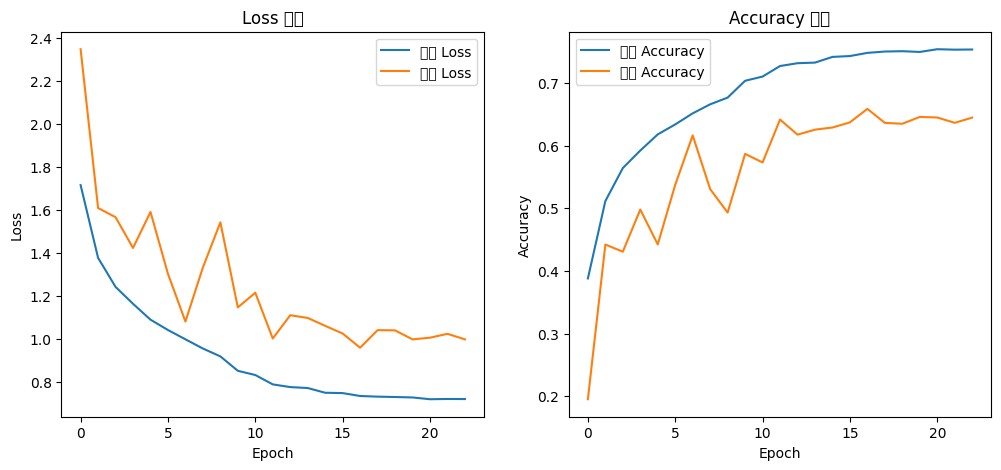

In [20]:
# 繪製 Loss 與 Accuracy 曲線
plt.figure(figsize=(12, 5))

# Loss 曲線
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='訓練 Loss')
plt.plot(history.history['val_loss'], label='驗證 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss 曲線')
plt.legend()

# Accuracy 曲線
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='訓練 Accuracy')
plt.plot(history.history['val_accuracy'], label='驗證 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy 曲線')
plt.legend()

plt.show()